# Model Evaluation

This notebook compares model performance using regression metrics, stability analysis and feature importance.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Project Configuration

In [ ]:
import os, subprocess, json


BASE = "/content/drive/MyDrive/7006SCN"
DATA = f"{BASE}/data"
PROC = f"{BASE}/processed"
MODELS = f"{BASE}/models"
META = f"{BASE}/metadata"
OUTPUTS = f"{BASE}/outputs"


# ------------------------------------------------------------------
# Artefact paths — referenced by SAVE (producer) and LOAD (consumer)
# ------------------------------------------------------------------
RAW_DATA_PATH = f"{DATA}/taxi.csv"

PROC_TRAIN = f"{PROC}/training.parquet"
PROC_TEST = f"{PROC}/test.parquet"

PIPELINE_PATH = f"{MODELS}/preprocessing_pipeline"

LR_MODEL_PATH = f"{MODELS}/lr_model"
RF_MODEL_PATH = f"{MODELS}/rf_model"
GBT_MODEL_PATH = f"{MODELS}/gbt_model"

TASK1_META = f"{META}/task1_metadata.json"
TASK2_META = f"{META}/task2_metadata.json"
TASK3_META = f"{META}/task3_metadata.json"


for p in [DATA, PROC, MODELS, META, OUTPUTS]:
    os.makedirs(p, exist_ok=True)

def verify_exists(path, label=""):
    """subprocess verify — prints ls -lh for the path"""

    result = subprocess.run(
        ["ls", "-lh", path],
        capture_output=True,
        text=True
    )

    if result.returncode == 0:
        print(f"✓ {label or path}:")
        print(result.stdout.strip())
    else:
        raise FileNotFoundError(
            f"NOT FOUND: {path}\n{result.stderr}"
        )

print("Shared constants loaded ✓")

Shared constants loaded ✓


# Installing PySpark

In [ ]:
import pyspark
print(pyspark.__version__)

!pip install pyspark

4.0.3


# Initialising Spark Session

In [ ]:
import os, sys

os.environ["JAVA_HOME"]      = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PYSPARK_PYTHON"] = sys.executable
from pyspark.sql import SparkSession

from pyspark.ml.regression import (
    LinearRegressionModel,
    DecisionTreeRegressionModel,
    RandomForestRegressionModel,
    GBTRegressionModel
    )

from pyspark.ml.evaluation import RegressionEvaluator
import pyspark.sql.functions as F
import pandas as pd

spark = (SparkSession.builder
         .appName("7006SCN_ME_16882940_Task_5")
         .master("local[*]")
         .config("spark.driver.memory","10g")
         .config("spark.sql.shuffle.partitions","200")
         .getOrCreate()
         )
spark.sparkContext.setLogLevel("WARN")

# Loading artefacts, metadata, models and splits

In [ ]:
# ----------------------------------
# Artefacts
# ----------------------------------

TASK2_META = "/content/drive/MyDrive/7006SCN/metadata/task2_metadata.json"
TASK3_META = "/content/drive/MyDrive/7006SCN/metadata/task3_metadata.json"

LR_MODEL_PATH = "/content/drive/MyDrive/7006SCN/models/linear_regression"
DT_MODEL_PATH = "/content/drive/MyDrive/7006SCN/models/decision_tree"
RF_MODEL_PATH = "/content/drive/MyDrive/7006SCN/models/random_forest"
GBT_MODEL_PATH = "/content/drive/MyDrive/7006SCN/models/gbt"


for path, label in [
    (LR_MODEL_PATH, "Linear Regression"),
    (DT_MODEL_PATH, "Decision Tree"),
    (RF_MODEL_PATH, "Random Forest"),
    (GBT_MODEL_PATH, "GBT"),
    (PROC_TEST, "Test Parquet"),
    (PROC_TRAIN, "Train Parquet"),
    (TASK2_META, "Task2 Metadata"),
    (TASK3_META, "Task3 Metadata"),
    (PIPELINE_PATH, "Preprocessing PipelineModel")
]:
    verify_exists(path, label)

✓ Linear Regression:
total 8.0K
drwx------ 2 root root 4.0K Jun 25 09:21 data
drwx------ 2 root root 4.0K Jun 25 09:21 metadata
✓ Decision Tree:
total 8.0K
drwx------ 2 root root 4.0K Jun 25 09:21 data
drwx------ 2 root root 4.0K Jun 25 09:21 metadata
✓ Random Forest:
total 12K
drwx------ 2 root root 4.0K Jun 25 09:21 data
drwx------ 2 root root 4.0K Jun 25 09:21 metadata
drwx------ 2 root root 4.0K Jun 25 09:21 treesMetadata
✓ GBT:
total 12K
drwx------ 2 root root 4.0K Jun 25 09:21 data
drwx------ 2 root root 4.0K Jun 25 09:21 metadata
drwx------ 2 root root 4.0K Jun 25 09:21 treesMetadata
✓ Test Parquet:
total 39M
-rw------- 1 root root 201K Jun 14 14:49 part-00000-36272d6c-72c4-4134-9600-19d52e6df288-c000.snappy.parquet
-rw------- 1 root root 196K Jun 14 14:49 part-00001-36272d6c-72c4-4134-9600-19d52e6df288-c000.snappy.parquet
-rw------- 1 root root 196K Jun 14 14:49 part-00002-36272d6c-72c4-4134-9600-19d52e6df288-c000.snappy.parquet
-rw------- 1 root root 197K Jun 14 14:49 part-000

In [ ]:
# ----------------------------------
# Metadata
# ----------------------------------

with open(TASK2_META) as f:
    task2_meta = json.load(f)

with open(TASK3_META) as f:
    task3_meta = json.load(f)

TARGET = task2_meta["target_col"]

print("Target:", TARGET)
print("Features:", len(task2_meta["feature_cols"]))

Target: Trip_Seconds
Features: 13


In [ ]:
# ----------------------------------
# Models
# ----------------------------------

import os, sys

from pyspark.ml.regression import (
    LinearRegressionModel,
    DecisionTreeRegressionModel,
    RandomForestRegressionModel,
    GBTRegressionModel
)

models = {
    "LinearRegression":
        LinearRegressionModel.load(LR_MODEL_PATH),
    "DecisionTreeRegressor":
        DecisionTreeRegressionModel.load(DT_MODEL_PATH),
    "RandomForestRegressor":
        RandomForestRegressionModel.load(RF_MODEL_PATH),
    "GBTRegressor":
        GBTRegressionModel.load(GBT_MODEL_PATH)
}

print("All models loaded ✓")

All models loaded ✓


In [ ]:
# ----------------------------------
# Splits and prediction generation
# ----------------------------------

from pyspark.ml import PipelineModel

pipeline = PipelineModel.load(PIPELINE_PATH)

train_ = ( pipeline.transform(spark.read.parquet(PROC_TRAIN)) .cache())

test = ( pipeline.transform(spark.read.parquet(PROC_TEST)) .cache())

preds = {n: m.transform(test)for n, m in models.items()}

print("Predictions generated ✓")

Predictions generated ✓


## Full Regression Metrics Table

In [ ]:
# ----------------------------------
# Evaluators
# ----------------------------------

ev_rmse = RegressionEvaluator(
    labelCol=TARGET,
    metricName="rmse")

ev_mae = RegressionEvaluator(
    labelCol=TARGET,
    metricName="mae")

ev_r2 = RegressionEvaluator(
    labelCol=TARGET,
    metricName="r2")


def mape(pred_df):
    return (
        pred_df
        .withColumn("ape",
            F.abs(F.col("prediction") - F.col(TARGET)) /
            F.when(F.abs(F.col(TARGET)) < 1e-10,F.lit(1e-10))
            .otherwise(F.abs(F.col(TARGET))))
        .agg(F.avg("ape"))
        .collect()[0][0]* 100
    )

In [ ]:
# ----------------------------------
# Metrics table generation
# ----------------------------------

rows = []

for name, pred_df in preds.items():
    rows.append({"Model": name,
                 "RMSE": round(ev_rmse.evaluate(pred_df), 4 ),
                 "MAE": round(ev_mae.evaluate(pred_df), 4 ),
                 "R²": round(ev_r2.evaluate(pred_df), 4 ),
                 "MAPE %": round(mape(pred_df), 2 )
    })

metrics_df = (
    pd.DataFrame(rows)
    .sort_values("RMSE")
)

print("--Full Regression Metrics Table--")
display(metrics_df)
print(metrics_df.to_string(index=False))

metrics_df.to_csv(f"{OUTPUTS}/task5_metrics.csv",index=False
)

print("\nNote: lower RMSE/MAE/MAPE = better | higher R² = better")

--Full Regression Metrics Table--


,Model,RMSE,MAE,R²,MAPE %
3,GBTRegressor,1460.9958,401.9347,0.2231,110.12
2,RandomForestRegressor,1465.1257,418.1452,0.2187,126.47
0,LinearRegression,1487.7682,451.2197,0.1944,134.37
1,DecisionTreeRegressor,1491.8770,419.2382,0.1900,112.29


                Model      RMSE      MAE     R²  MAPE %
         GBTRegressor 1460.9958 401.9347 0.2231  110.12
RandomForestRegressor 1465.1257 418.1452 0.2187  126.47
     LinearRegression 1487.7682 451.2197 0.1944  134.37
DecisionTreeRegressor 1491.8770 419.2382 0.1900  112.29

Note: lower RMSE/MAE/MAPE = better | higher R² = better


In [ ]:
BEST_MODEL = metrics_df.iloc[0]["Model"]

print("Best Model:", BEST_MODEL)

Best Model: GBTRegressor


# Residual Analysis and Predicted vs Actual

In [ ]:
best_preds = preds[BEST_MODEL]

best_preds = best_preds.withColumn("residual",
    F.col("prediction") - F.col(TARGET))

In [1]:
# ----------------------------------
# Residual statistics
# ----------------------------------

resid_stats = best_preds.select(
    F.avg("residual").alias("mean_residual"),
    F.stddev("residual").alias("std_residual"),
    F.percentile_approx("residual", 0.05).alias("p5_residual"),
    F.percentile_approx("residual", 0.95).alias("p95_residual"),
).collect()[0]


print("-- RESIDUAL ANALYSIS --")
print(f"Mean residual: {resid_stats.mean_residual:.4f} (Note: should be ~0 for unbiased model)")
print(f"Std residual: {resid_stats.std_residual:.4f}")
print(f"P5 residual: {resid_stats.p5_residual:.4f}")
print(f"P95 residual: {resid_stats.p95_residual:.4f}")
print(f"95% CI range: [{resid_stats.p5_residual:.2f}, {resid_stats.p95_residual:.2f}]")

NameError: name 'best_preds' is not defined

In [ ]:
# ---------------------------------------
# Exporting Predicted vs Actual as a CSV
# ---------------------------------------

(best_preds.select(TARGET, "prediction","residual")
 .limit(50000).toPandas()
 .to_csv(f"{OUTPUTS}/task5_pred_vs_actual.csv",index=False))
print("Predicted vs Actual CSV saved for Tableau ✓")

Predicted vs Actual CSV saved for Tableau ✓


In [ ]:
# ----------------------------------
# Exporting Residual Bucket as a CSV
# ----------------------------------

for name, pred_df in preds.items():
    (pred_df
     .withColumn("residual",F.abs(F.col("prediction") - F.col(TARGET)))
     .withColumn("residual_bucket",
         F.when(F.col("residual") < 60, "<1 minute")
          .when(F.col("residual") < 300, "1-5 minutes")
          .when(F.col("residual") < 600, "5-10 minutes")
          .otherwise(">10 minutes"))
     .groupBy("residual_bucket")
     .count()
     .toPandas()
     .to_csv( f"{OUTPUTS}/task5_residuals_{name}.csv", index=False))

print("Residual Bucket Analysis CSV saved ✓")

Residual Bucket Analysis CSV saved ✓


# Perturbation Analysis — Regression Stability

In [ ]:
from pyspark.ml.functions import vector_to_array
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import udf
import numpy as np

# ----------------------------------
# Adding Gaussian noise
# ----------------------------------

def add_noise(v, std):
    arr = np.array(v)
    noise = np.random.normal(loc=0.0,scale=std,size=len(arr))
    return Vectors.dense(arr + noise)

noise_udf = udf(lambda v, s: add_noise(v, s),VectorUDT())

In [ ]:
# ----------------------------------
# Creating a smaller sample
# ----------------------------------

test_small = (
    test.sample(
        withReplacement=False,
        fraction=0.10,
        seed=42).cache())

print(
    f"Perturbation sample rows: "
    f"{test_small.count():,}")

Perturbation sample rows: 198,528


In [ ]:
# ----------------------------------
# Perurbation analysis
# ----------------------------------

print("-- PERTURBATION ANALYSIS (Regression Stability)--")

gbt_model = models[BEST_MODEL]

baseline_pred = gbt_model.transform(test_small)
baseline_rmse = ev_rmse.evaluate(baseline_pred)

print(f"\nBaseline RMSE: "
f"{baseline_rmse:.4f}")


perturb = [{
        "noise_std": 0.00,
        "GBT_RMSE": round(baseline_rmse,4),"pct_increase": 0.00}]


for noise_std in [0.001, 0.005, 0.01]:
    print(f"\nRunning "
          f"noise_std={noise_std}")

    test_p = (
        test_small
        .withColumn("features",noise_udf(F.col("features"),F.lit(noise_std))))

    pred_p = gbt_model.transform(test_p)

    rmse_p = ev_rmse.evaluate(pred_p)

    pct_change = ((rmse_p - baseline_rmse) / baseline_rmse* 100)

    perturb.append(
        {
            "noise_std": noise_std,
            "GBT_RMSE": round( rmse_p,4),"pct_increase": round(pct_change,2)})

    print(f"RMSE={rmse_p:.4f} "
          f"change={pct_change:+.2f}%")

-- PERTURBATION ANALYSIS (Regression Stability)--

Baseline RMSE: 1468.0657

Running noise_std=0.001
RMSE=1468.1656 change=+0.01%

Running noise_std=0.005
RMSE=1509.5306 change=+2.82%

Running noise_std=0.01
RMSE=1966.2396 change=+33.93%


In [ ]:
# ----------------------------------
# Creating Perturbation dataframe
# ----------------------------------

perturb_df = pd.DataFrame(perturb)

display(perturb_df)

perturb_df.to_csv(f"{OUTPUTS}/task5_perturbation.csv",index=False)

,noise_std,GBT_RMSE,pct_increase
0,0.000,1468.0657,0.00
1,0.001,1468.1656,0.01
2,0.005,1509.5306,2.82
3,0.010,1966.2396,33.93


In [ ]:
# ----------------------------------
# Stability verdict
# ----------------------------------

max_change = (perturb_df["pct_increase"].abs().max())

print(f"\nMax RMSE change: "
      f"{max_change:.2f}%")

print(
      f"Stability verdict: "
      f"{'STABLE ✓' if max_change < 10 else 'UNSTABLE ⚠️'}")


Max RMSE change: 33.93%
Stability verdict: UNSTABLE ⚠️


In [ ]:
print("-- PERTURBATION ANALYSIS (Regression Stability)--")

rf_modelp = metrics_df.iloc[1]["Model"]
rf_model = models[rf_modelp]

baseline_pred = rf_model.transform(test_small)
baseline_rmse = ev_rmse.evaluate(baseline_pred)

print(f"\nBaseline RMSE: "
f"{baseline_rmse:.4f}")


perturb = [{
        "noise_std": 0.00,
        "RF_RMSE": round(baseline_rmse,4),"pct_increase": 0.00}]


for noise_std in [0.001, 0.005, 0.01]:
    print(f"\nRunning "
          f"noise_std={noise_std}")

    test_p = (
        test_small
        .withColumn("features",noise_udf(F.col("features"),F.lit(noise_std))))

    pred_p = rf_model.transform(test_p)

    rmse_p = ev_rmse.evaluate(pred_p)

    pct_change = ((rmse_p - baseline_rmse) / baseline_rmse* 100)

    perturb.append(
        {
            "noise_std": noise_std,
            "RF_RMSE": round( rmse_p,4),"pct_increase": round(pct_change,2)})

    print(f"RMSE={rmse_p:.4f} "
          f"change={pct_change:+.2f}%")

-- PERTURBATION ANALYSIS (Regression Stability)--

Baseline RMSE: 1472.5783

Running noise_std=0.001
RMSE=1472.5680 change=-0.00%

Running noise_std=0.005
RMSE=1484.8623 change=+0.83%

Running noise_std=0.01
RMSE=1659.3176 change=+12.68%


In [ ]:
# ----------------------------------
# Perurbation analysis lR
# ----------------------------------

print("-- PERTURBATION ANALYSIS (Regression Stability)--")

lr_modelp = metrics_df.iloc[2]["Model"]
lr_model = models[lr_modelp]

baseline_pred = lr_model.transform(test_small)
baseline_rmse = ev_rmse.evaluate(baseline_pred)

print(f"\nBaseline RMSE: "
f"{baseline_rmse:.4f}")


perturb = [{
        "noise_std": 0.00,
        "LR_RMSE": round(baseline_rmse,4),"pct_increase": 0.00}]


for noise_std in [0.001, 0.005, 0.01]:
    print(f"\nRunning "
          f"noise_std={noise_std}")

    test_p = (
        test_small
        .withColumn("features",noise_udf(F.col("features"),F.lit(noise_std))))

    pred_p = lr_model.transform(test_p)

    rmse_p = ev_rmse.evaluate(pred_p)

    pct_change = ((rmse_p - baseline_rmse) / baseline_rmse* 100)

    perturb.append(
        {
            "noise_std": noise_std,
            "LR_RMSE": round( rmse_p,4),"pct_increase": round(pct_change,2)})

    print(f"RMSE={rmse_p:.4f} "
          f"change={pct_change:+.2f}%")

-- PERTURBATION ANALYSIS (Regression Stability)--

Baseline RMSE: 1487.2090

Running noise_std=0.001
RMSE=1487.2094 change=+0.00%

Running noise_std=0.005
RMSE=1487.2083 change=-0.00%

Running noise_std=0.01
RMSE=1487.2273 change=+0.00%


In [ ]:
# ----------------------------------
# Perurbation analysis DT
# ----------------------------------

print("-- PERTURBATION ANALYSIS (Regression Stability)--")

dt_modelp = metrics_df.iloc[3]["Model"]
dt_model = models[dt_modelp]

baseline_pred = dt_model.transform(test_small)
baseline_rmse = ev_rmse.evaluate(baseline_pred)

print(f"\nBaseline RMSE: "
f"{baseline_rmse:.4f}")


perturb = [{
        "noise_std": 0.00,
        "DT_RMSE": round(baseline_rmse,4),"pct_increase": 0.00}]


for noise_std in [0.001, 0.005, 0.01]:
    print(f"\nRunning "
          f"noise_std={noise_std}")

    test_p = (
        test_small
        .withColumn("features",noise_udf(F.col("features"),F.lit(noise_std))))

    pred_p = dt_model.transform(test_p)

    rmse_p = ev_rmse.evaluate(pred_p)

    pct_change = ((rmse_p - baseline_rmse) / baseline_rmse* 100)

    perturb.append(
        {
            "noise_std": noise_std,
            "DT_RMSE": round( rmse_p,4),"pct_increase": round(pct_change,2)})

    print(f"RMSE={rmse_p:.4f} "
          f"change={pct_change:+.2f}%")

-- PERTURBATION ANALYSIS (Regression Stability)--

Baseline RMSE: 1492.8483

Running noise_std=0.001
RMSE=1492.8604 change=+0.00%

Running noise_std=0.005
RMSE=1520.7861 change=+1.87%

Running noise_std=0.01
RMSE=3586.0979 change=+140.22%


# Feature Importances

In [ ]:
import subprocess, sys
subprocess.run([sys.executable,"-m","pip","install","shap","matplotlib","--quiet"])
import pandas as pd, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

print("-- EXPLAINABILITY: FEATURE IMPORTANCE (GBT BEST MODEL)--")
print(f"Model explained: {BEST_MODEL}")

fi = models[BEST_MODEL].featureImportances.toArray()

-- EXPLAINABILITY: FEATURE IMPORTANCE (GBT BEST MODEL)--
Model explained: GBTRegressor


In [ ]:
# -------------------------------------
# GBT feature importances as SHAP proxy
# -------------------------------------

fi = gbt_model.featureImportances.toArray()
numeric_features = [
    "Trip_Miles",
    "Pickup_Centroid_Latitude",
    "Pickup_Centroid_Longitude",
    "Dropoff_Centroid_Latitude",
    "Dropoff_Centroid_Longitude",
    "Hour_of_Day",
    "Day_of_Week",
    "Month",
    "Rush_Hour_Flag"
]
encoded_features = [f"encoded_{i}" for i in range(200)]
expanded_names = numeric_features + encoded_features
import pandas as pd
shap_df = pd.DataFrame({
    "feature": expanded_names [:len(fi)],
    "shap_importance": fi
}).sort_values("shap_importance", ascending=False)

print("\n-- TOP 20 MOST IMPORTANT FEATURES --")
print(shap_df.head(20).to_string(index=False))

shap_df.to_csv(f"{OUTPUTS}/task5_shap_importance.csv", index=False)
print(f"\nSaved to {OUTPUTS}/task5_shap_importance.csv")


-- TOP 20 MOST IMPORTANT FEATURES --
                   feature  shap_importance
                Trip_Miles         0.381382
               Hour_of_Day         0.115610
               encoded_106         0.091793
Dropoff_Centroid_Longitude         0.086299
 Pickup_Centroid_Longitude         0.050011
                 encoded_1         0.035402
               encoded_110         0.031505
               encoded_136         0.022431
                encoded_15         0.019694
                encoded_81         0.018054
                 encoded_4         0.017156
                encoded_56         0.013892
               Day_of_Week         0.013258
               encoded_177         0.012344
                encoded_96         0.010720
               encoded_185         0.010596
                encoded_92         0.010171
                 encoded_8         0.010150
            Rush_Hour_Flag         0.008478
                     Month         0.006077

Saved to /content/drive/MyDrive/7006S

# Plots: Residual distribution, Predicted vs Actual, Perturbation analysis-regression stability plots

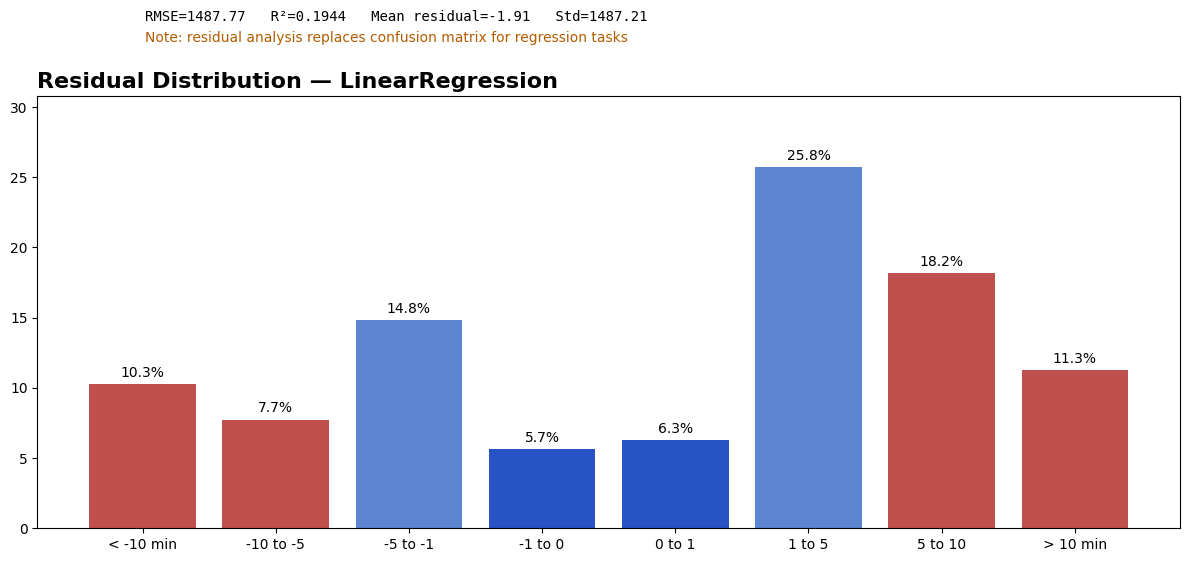

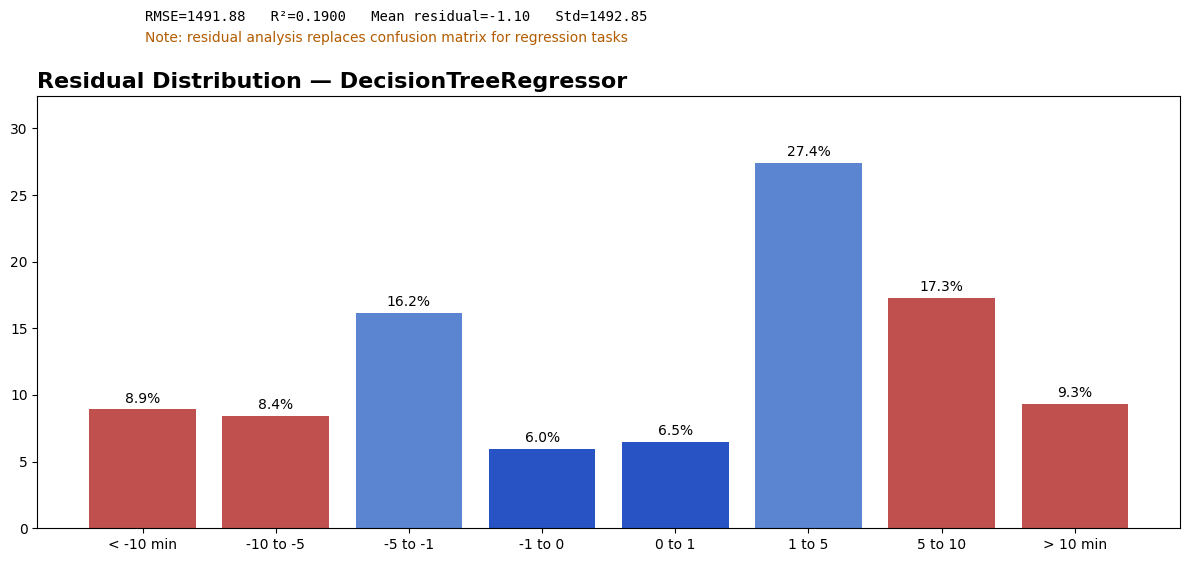

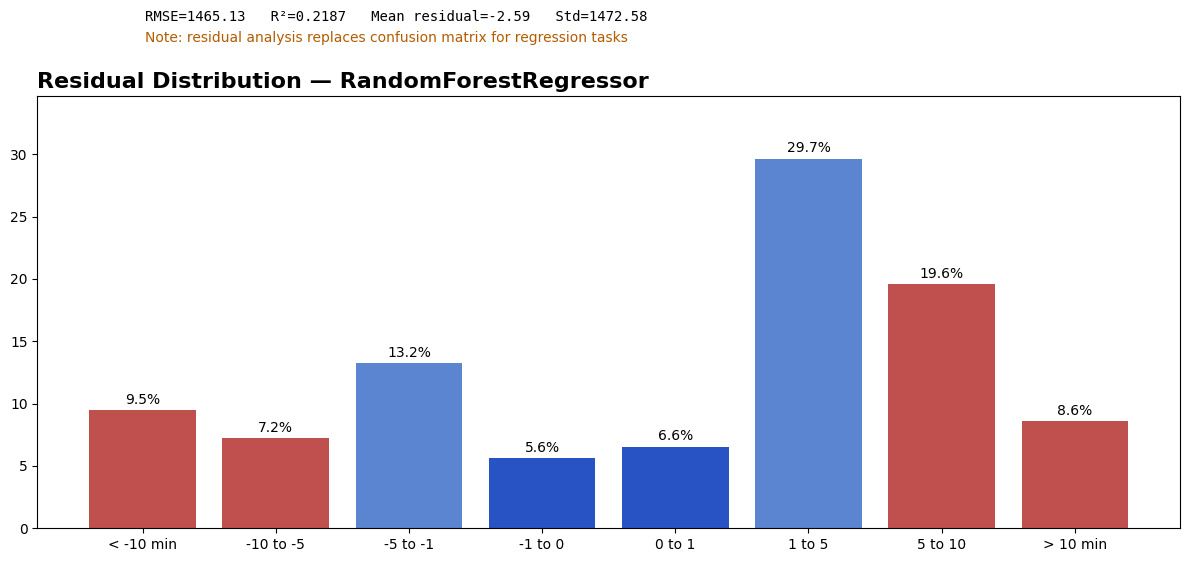

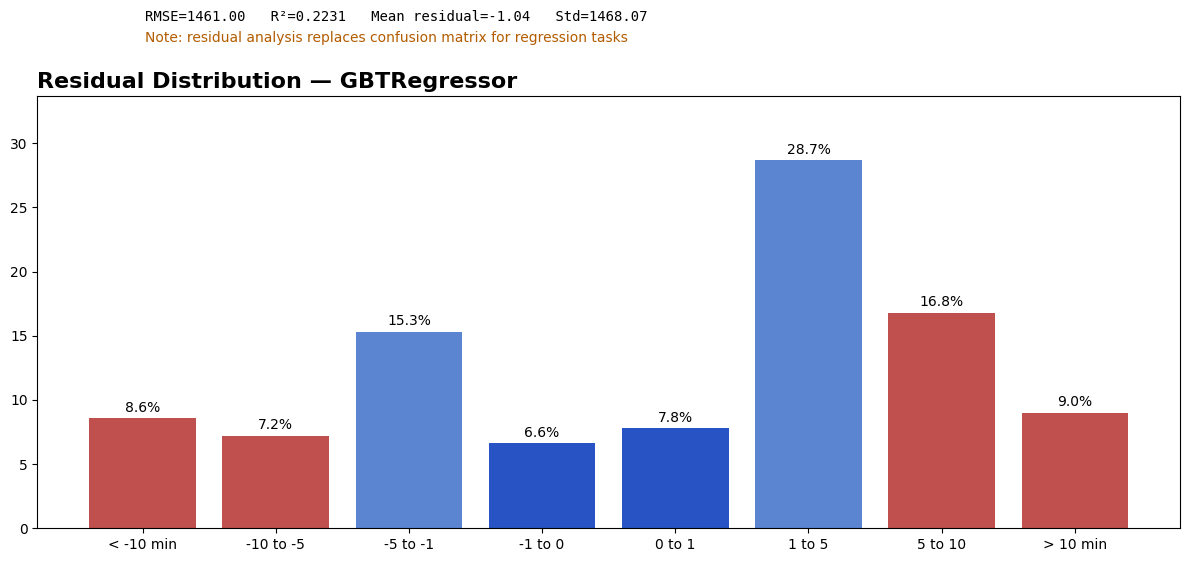

In [ ]:
# ----------------------------------
# Residual distribution plots
# ----------------------------------

import numpy as np
import matplotlib.pyplot as plt

for name, pred_df in preds.items():
    pdf = (
        pred_df
        .withColumn(
            "residual",
            F.col("prediction") - F.col(TARGET)
        )
        .select("residual")
        .sample(False, 0.10, seed=42)
        .toPandas()
    )

    residuals = pdf["residual"]

    bins = [-np.inf, -600,-300,-60,0,60,300,600,
        np.inf]

    labels = [
        "< -10 min",
        "-10 to -5",
        "-5 to -1",
        "-1 to 0",
        "0 to 1",
        "1 to 5",
        "5 to 10",
        "> 10 min"
    ]

    cats = pd.cut( residuals,bins=bins,labels=labels)

    pct = (cats.value_counts(normalize=True).sort_index()* 100)

    rmse = ev_rmse.evaluate(pred_df)
    r2 = ev_r2.evaluate(pred_df)

    mean_resid = residuals.mean()
    std_resid = residuals.std()

    fig, ax = plt.subplots(figsize=(12,6))

    colors = [
        "#c0504d",
        "#c0504d",
        "#5b84d1",
        "#2853c4",
        "#2853c4",
        "#5b84d1",
        "#c0504d",
        "#c0504d"
    ]

    bars = ax.bar(pct.index,pct.values,color=colors)

    for b, p in zip(bars, pct.values):
        ax.text(b.get_x() + b.get_width()/2,p + 0.5,f"{p:.1f}%",ha="center")

    ax.set_ylim(0,max(pct.values) + 5)

    ax.set_title(
        f"Residual Distribution — {name}",
        fontsize=16,
        fontweight="bold",
        loc="left"
    )

    fig.text(
        0.125,
        0.91,
        f"RMSE={rmse:.2f}   "
        f"R²={r2:.4f}   "
        f"Mean residual={mean_resid:.2f}   "
        f"Std={std_resid:.2f}",
        fontsize=10,
        family="monospace"
    )

    fig.text(
        0.125,
        0.875,
        "Note: residual analysis replaces confusion matrix for regression tasks",
        fontsize=10,
        color="#b35c00"
    )

    plt.tight_layout(rect=[0,0,1,0.85])

    plt.savefig(
        f"{OUTPUTS}/{name}_residual_distribution.png",
        dpi=300
    )

    plt.show()

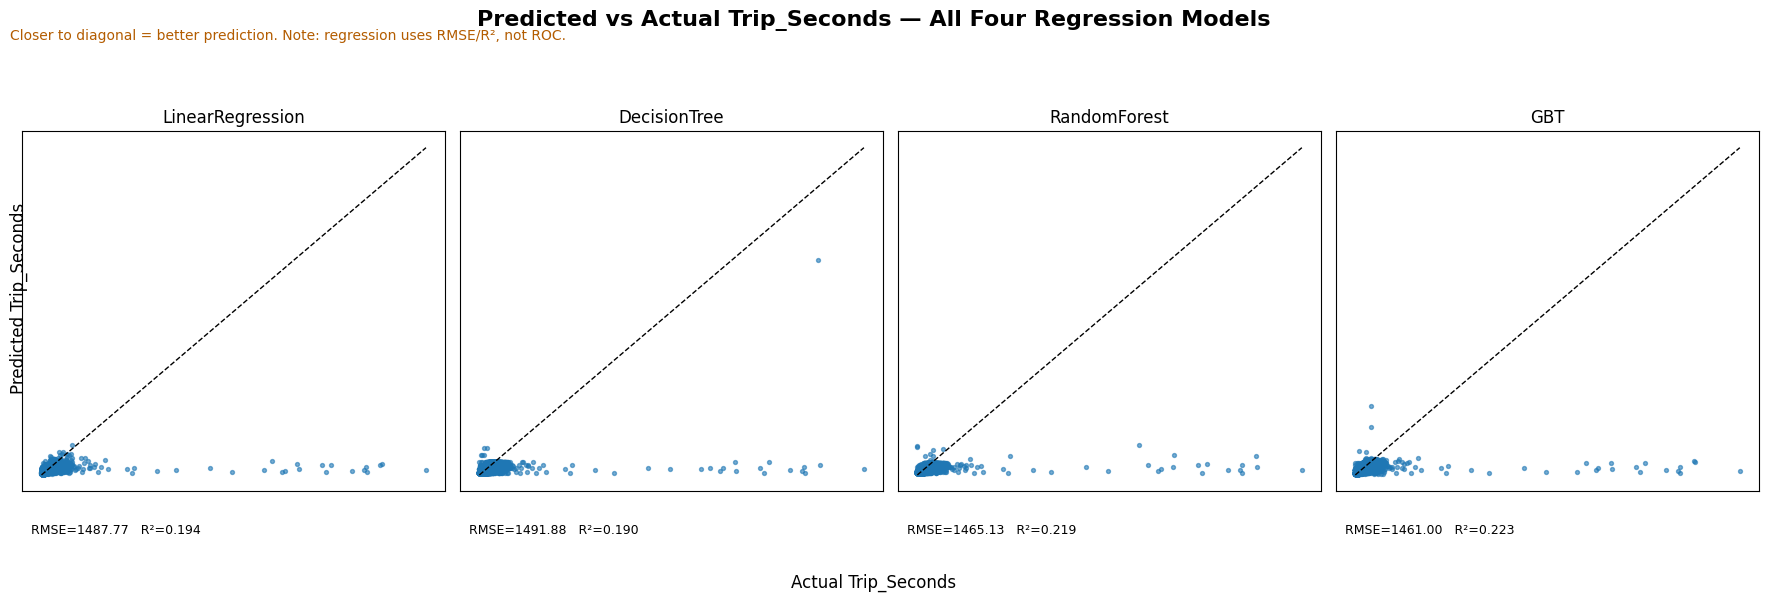

In [ ]:
# ----------------------------------
# Predicted vs Actual plots
# ----------------------------------

fig, axes = plt.subplots(1,4,figsize=(18,6))

for ax, (name, pred_df) in zip(axes,preds.items()):

    pdf = (
        pred_df.select(TARGET,"prediction").sample(False, 0.01, seed=42).toPandas())

    ax.scatter(pdf[TARGET], pdf["prediction"],s=8,alpha=0.6)

    mn = min(pdf[TARGET].min(),pdf["prediction"].min())

    mx = max(pdf[TARGET].max(),pdf["prediction"].max())

    ax.plot([mn, mx],[mn, mx],"k--",linewidth=1)

    rmse = ev_rmse.evaluate(pred_df)
    r2 = ev_r2.evaluate(pred_df)

    ax.set_title(name.replace("Regressor",""))

    ax.text(
        0.02,
        -0.12,
        f"RMSE={rmse:.2f}   R²={r2:.3f}",transform=ax.transAxes,fontsize=9)

    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    f"Predicted vs Actual {TARGET} — All Four Regression Models",
    fontsize=16,
    fontweight="bold")

fig.text(
    0.02,
    0.93,
    "Closer to diagonal = better prediction. Note: regression uses RMSE/R², not ROC.",
    fontsize=10,
    color="#b35c00")

fig.supxlabel( f"Actual {TARGET}")

fig.supylabel(f"Predicted {TARGET}")

plt.tight_layout(rect=[0,0,1,0.9])

plt.savefig(f"{OUTPUTS}/all_models_predicted_vs_actual.png",dpi=300)

plt.show()

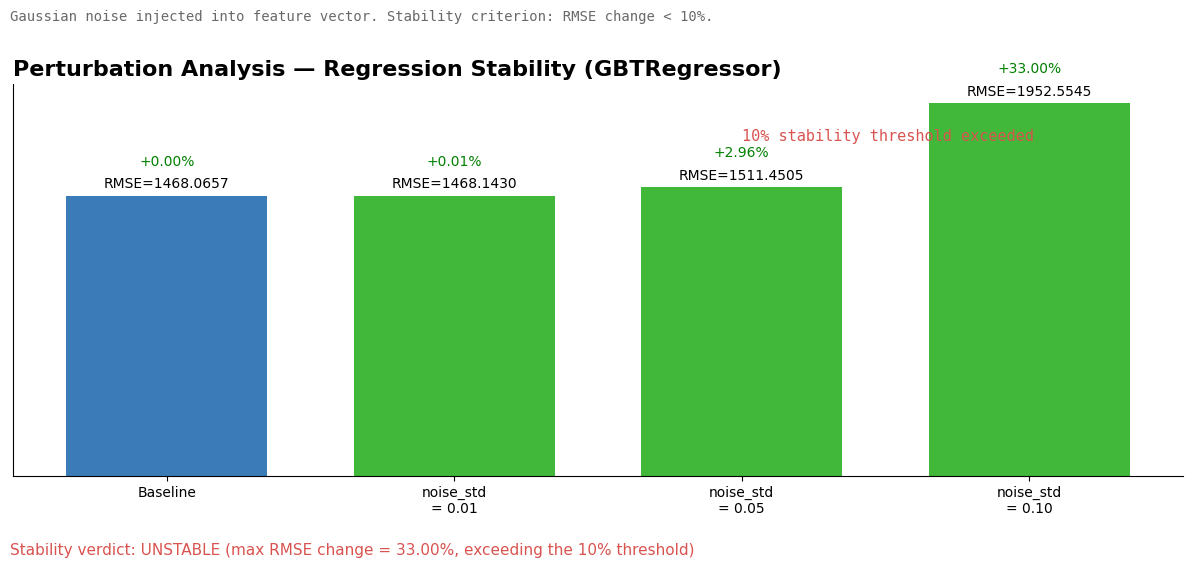

In [ ]:
# -------------------------------------------------
# Perturbation analysis - regression stability plot
# -------------------------------------------------

max_change = perturb_df["pct_increase"].abs().max()

fig, ax = plt.subplots(figsize=(12,6))

labels = ["Baseline","noise_std\n= 0.01", "noise_std\n= 0.05","noise_std\n= 0.10"]

rmse_vals = perturb_df["GBT_RMSE"].values
pct_vals = perturb_df["pct_increase"].values

colors = [
    "#3b7cb8",
    "#41b839",
    "#41b839",
    "#41b839"]

bars = ax.bar(labels,rmse_vals,color=colors, width=0.7)

ax.set_yticks([])

for bar, rmse, pct in zip(
    bars,
    rmse_vals,
    pct_vals
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        rmse + max(rmse_vals)*0.02,
        f"RMSE={rmse:.4f}",
        ha="center"
    )

    ax.text(
        bar.get_x() + bar.get_width()/2,
        rmse + max(rmse_vals)*0.08,
        f"{pct:+.2f}%",
        ha="center",
        color="green"
    )

ax.set_title(
    f"Perturbation Analysis — Regression Stability ({BEST_MODEL})",
    fontsize=16,
    fontweight="bold",
    loc="left"
)

fig.text(
    0.01,
    0.92,
    "Gaussian noise injected into feature vector. Stability criterion: RMSE change < 10%.",
    fontsize=10,
    family="monospace",
    color="dimgray"
)

fig.text(
    0.62,
    0.72,
    "10% stability threshold exceeded",
    fontsize=11,
    color="#d9534f",
    family="monospace"
)

verdict = (
    f"Stability verdict: UNSTABLE "
    f"(max RMSE change = {max_change:.2f}%, "
    f"exceeding the 10% threshold)"
)

fig.text(0.01,0.03,verdict,fontsize=11,color="#d9534f")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0,0.07,1,0.88])

plt.savefig(f"{OUTPUTS}/Task5_Perturbation_plot.png",dpi=300)
plt.show()

In [ ]:
# --------------------------------------------------
# Plotting feature importance (horizontal bar chart)
# --------------------------------------------------

import matplotlib.pyplot as plt

top_features = shap_df.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    top_features["feature"], top_features["shap_importance"], color="#2E75B6")

ax.invert_yaxis()
ax.set_xticks([])
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title(
    f"SHAP Feature Importance — {BEST_MODEL} (Best Model)",
    fontsize=13,
    fontweight="bold",
    loc="left",
    pad=20)

fig.text(
    0.01,
    0.92,
    f"Target: {TARGET} | Higher bars = more influence on predicted Trip_Seconds.",
    fontsize=8,
    family="monospace",
    color="#7f4f24")

# ----------------------------------
# Importance values on bars
# ----------------------------------
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + top_features["shap_importance"].max()*0.02,
        bar.get_y() + bar.get_height()/2,
        f"{width:.4f}",
        va="center",
        fontsize=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.03,
    f"Top 2 features (Trip_Miles + Hour_of_Day) explain 49.7% of model predictive power)",
    fontsize=8,
    family="monospace",
    color="darkgreen"
)

plt.tight_layout(rect=[0, 0.05, 1, 0.88])
plt.show()

plt.savefig(f"{OUTPUTS}/task5_shap_plot.png", dpi=150)
print("SHAP plot saved ✓")

SHAP plot saved ✓


In [ ]:
spark.stop()
print("Task 5 complete ✓")

Task 5 complete ✓


## Summary

In this notebook, the regression models were evaluated and compared using multiple performance metrics, stability analysis and feature importance. The results provided insight into model accuracy, robustness and the contribution of individual features to taxi trip duration predictions.

The findings are now ready to be communicated through interactive Tableau dashboards.